## Kết nối drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Lấy Dữ Liệu Dataset từ drive xong giải nén

In [ ]:
!cp /content/drive/MyDrive/machine_learning/data/split.zip /content/
!unzip -q /content/split.zip -d /content/dataset_local

## Bắt Dầu Train

In [ ]:
# ==========================================
# BƯỚC 1: KẾT NỐI VÀ THIẾT LẬP (Google Colab)
# ==========================================

import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import drive

# 1.1. Kết nối với Google Drive để lấy dữ liệu
# Sau khi chạy dòng này, hãy nhấp vào liên kết hiện ra để cấp quyền truy cập.
# drive.mount('/content/drive')

# 1.2. Đường dẫn đến thư mục dữ liệu trên Google Drive của bạn
# QUAN TRỌNG: Bạn cần thay đổi đường dẫn này thành đường dẫn thực tế trên Drive của bạn!
# Giả sử bạn để thư mục dữ liệu trong thư mục gốc của Drive với tên là "DuLieuTraiCay"
BASE_DIR = '/content/dataset_local/split'

train_dir = os.path.join(BASE_DIR, 'train')
val_dir = os.path.join(BASE_DIR, 'val')
test_dir = os.path.join(BASE_DIR, 'test')

# 1.3. Khai báo các tham số cơ bản
IMG_HEIGHT, IMG_WIDTH = 224, 224  # Kích thước ảnh đầu vào cho mô hình
BATCH_SIZE = 32                  # Số lượng ảnh xử lý trong một lần huấn luyện
NUM_CLASSES = 3                   # Số lượng nhãn (ripe, unripe, rotten)
EPOCHS = 20                        # Số lượt huấn luyện qua toàn bộ tập dữ liệu

# ==========================================
# BƯỚC 2: TIỀN XỬ LÝ VÀ TĂNG CƯỜNG DỮ LIỆU ẢNH
# ==========================================
# Chúng ta sẽ sử dụng ImageDataGenerator của Keras để thực hiện việc này.
# Nhờ cấu trúc thư mục của bạn, Keras sẽ tự động gán nhãn dựa trên tên thư mục.

# 2.1. Thiết lập cho tập Huấn luyện (Train)
# Tăng cường dữ liệu (Data Augmentation) để giúp mô hình mạnh mẽ hơn, tránh học vẹt.
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Chuẩn hóa giá trị pixel ảnh về khoảng [0, 1]
    rotation_range=20,        # Xoay ảnh ngẫu nhiên tối đa 20 độ
    width_shift_range=0.2,    # Dịch chuyển ảnh theo chiều ngang tối đa 20%
    height_shift_range=0.2,   # Dịch chuyển ảnh theo chiều dọc tối đa 20%
    horizontal_flip=True,     # Lật ảnh ngẫu nhiên theo chiều ngang
    zoom_range=0.2,            # Phóng to/thu nhỏ ảnh ngẫu nhiên tối đa 20%
    fill_mode='nearest'       # Cách lấp đầy các khoảng trống khi xoay/dịch ảnh
)

# 2.2. Thiết lập cho tập Kiểm thử (Validation) và Kiểm tra (Test)
# Với hai tập này, chúng ta CHỈ CHUẨN HÓA, không tăng cường dữ liệu.
validation_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# 2.3. Tạo các Data Generators thực tế để nạp dữ liệu vào mô hình
print("--- Loading Training Data ---")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH), # Chuẩn hóa kích thước ảnh
    batch_size=BATCH_SIZE,
    class_mode='categorical'             # Chế độ phân loại nhiều lớp
)

print("\n--- Loading Validation Data ---")
validation_generator = validation_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print("\n--- Loading Test Data ---")
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False                      # Không xáo trộn dữ liệu tập test để dễ đánh giá sau này
)

# Hiển thị các nhãn lớp và chỉ số tương ứng
print(f"\nDanh sách nhãn lớp và chỉ số: {train_generator.class_indices}")
# Kết quả thường là {'ripe': 0, 'rotten': 1, 'unripe': 2}

# ==========================================
# BƯỚC 3: XÂY DỰNG MÔ HÌNH CNN ĐƠN GIẢN
# ==========================================
# Đây chính là kiến trúc mà chúng ta đã thảo luận.

model = models.Sequential([
    # Lớp tích chập thứ 1: Học các đặc trưng đơn giản (đường viền, cạnh)
    # 32 bộ lọc (filters) kích thước 3x3, hàm kích hoạt ReLU
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    # Lớp gộp thứ 1: Giảm kích thước ảnh, giữ lại đặc trưng nổi bật
    layers.MaxPooling2D((2, 2)),

    # Lớp tích chập thứ 2: Học các đặc trưng phức tạp hơn (màu sắc, kết cấu)
    layers.Conv2D(64, (3, 3), activation='relu'),
    # Lớp gộp thứ 2
    layers.MaxPooling2D((2, 2)),

    # Lớp tích chập thứ 3: Học các chi tiết sâu hơn
    layers.Conv2D(128, (3, 3), activation='relu'),
    # Lớp gộp thứ 3
    layers.MaxPooling2D((2, 2)),

    # Chuyển đổi dữ liệu từ 2D sang 1D để đưa vào lớp kết nối đầy đủ
    layers.Flatten(),

    # Lớp kết nối đầy đủ (Dense): Học các luật kết hợp từ các đặc trưng đã trích xuất
    layers.Dense(128, activation='relu'),
    # Lớp Dropout để tránh overfitting bằng cách ngắt ngẫu nhiên 50% nơ-ron trong quá trình huấn luyện
    layers.Dropout(0.5),

    # Lớp đầu ra: Số lượng nơ-ron bằng số lớp (3), hàm activation 'softmax'
    # Softmax giúp đưa ra kết quả dưới dạng xác suất cho mỗi nhãn.
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# Xem tóm tắt cấu trúc mô hình
model.summary()


# ==========================================
# BƯỚC 4: CẤU HÌNH VÀ HUẤN LUYỆN MÔ HÌNH
# ==========================================

# 4.1. Cấu hình mô hình
model.compile(
    optimizer='adam',                   # Thuật toán tối ưu hóa Adam phổ biến và hiệu quả
    loss='categorical_crossentropy',     # Hàm mất mát cho bài toán phân loại đa lớp
    metrics=['accuracy']                  # Chỉ số đánh giá mô hình là độ chính xác
)

# 4.2. Huấn luyện mô hình
# Quá trình này có thể mất thời gian tùy thuộc vào số lượng ảnh và GPU của bạn.
print("\n--- Bắt đầu huấn luyện mô hình ---")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator
)
print("--- Kết thúc huấn luyện ---")

# ==========================================
# BƯỚC 5: ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST
# ==========================================
# Đây là bước quan trọng để biết mô hình hoạt động như thế nào với dữ liệu hoàn toàn chưa gặp.

print("\n--- Đánh giá mô hình trên tập Test ---")
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Độ chính xác trên tập Test: {test_accuracy*100:.2f}%")
print(f"Mất mát trên tập Test: {test_loss:.4f}")

# (Tùy chọn) Lưu mô hình lại để sử dụng sau này
model.save('fruit_ripeness_model.h5')
print("\nĐã lưu mô hình thành công.")

--- Loading Training Data ---
Found 13655 images belonging to 3 classes.

--- Loading Validation Data ---
Found 3902 images belonging to 3 classes.

--- Loading Test Data ---
Found 1953 images belonging to 3 classes.

Danh sách nhãn lớp và chỉ số: {'Ripe_preprocessed': 0, 'Rotten_preprocessed': 1, 'Unripe_preprocessed': 2}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)


--- Bắt đầu huấn luyện mô hình ---
Epoch 1/20
427/427 ━━━━━━━━━━━━━━━━━━━━ 199s 447ms/step - accuracy: 0.8128 - loss: 0.4903 - val_accuracy: 0.8255 - val_loss: 0.5457
Epoch 2/20
427/427 ━━━━━━━━━━━━━━━━━━━━ 182s 427ms/step - accuracy: 0.8595 - loss: 0.3780 - val_accuracy: 0.8870 - val_loss: 0.2886
Epoch 3/20
427/427 ━━━━━━━━━━━━━━━━━━━━ 186s 436ms/step - accuracy: 0.8719 - loss: 0.3459 - val_accuracy: 0.8783 - val_loss: 0.3234
Epoch 4/20
427/427 ━━━━━━━━━━━━━━━━━━━━ 181s 424ms/step - accuracy: 0.8816 - loss: 0.3108 - val_accuracy: 0.8980 - val_loss: 0.2681
Epoch 5/20
427/427 ━━━━━━━━━━━━━━━━━━━━ 180s 420ms/step - accuracy: 0.8896 - loss: 0.2986 - val_accuracy: 0.9075 - val_loss: 0.2365
Epoch 6/20
427/427 ━━━━━━━━━━━━━━━━━━━━ 182s 426ms/step - accuracy: 0.8966 - loss: 0.2724 - val_accuracy: 0.9193 - val_loss: 0.2283
Epoch 7/20
427/427 ━━━━━━━━━━━━━━━━━━━━ 180s 421ms/step - accuracy: 0.9019 - loss: 0.2648 - val_accuracy: 0.9280 - val_loss: 0.1944
Epoch 8/20
427/427 ━━━━━━━━━━━━━━━━━━━━ 

Độ chính xác trên tập Test: 95.39%
Mất mát trên tập Test: 0.1335

Đã lưu mô hình thành công.


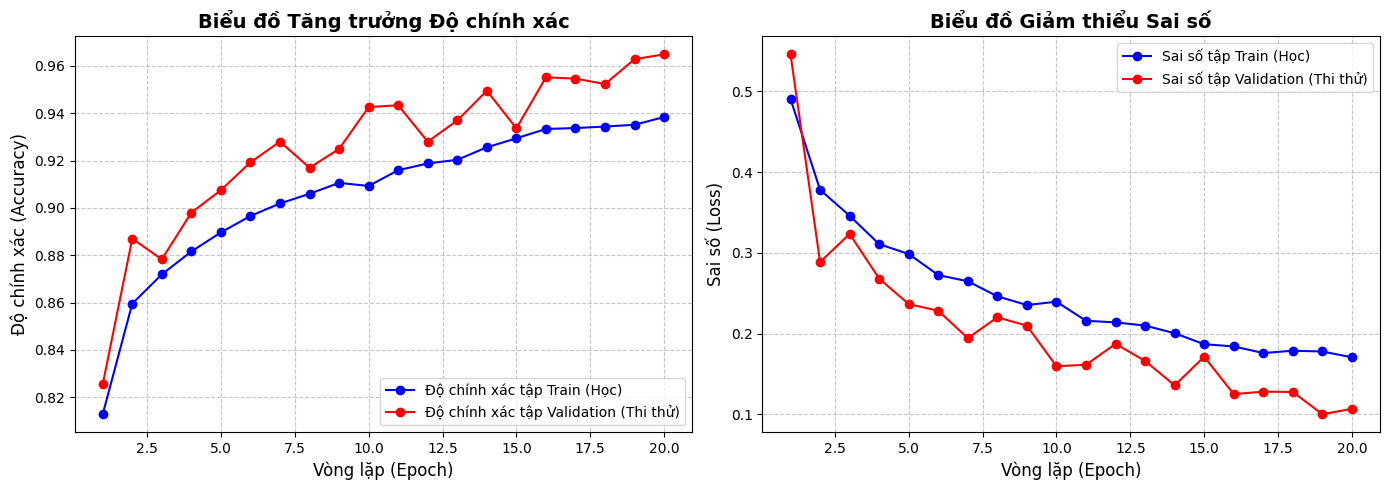

In [ ]:
import matplotlib.pyplot as plt

# Lấy dữ liệu từ quá trình huấn luyện (biến 'history' đã lưu lại mọi thông số)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Tạo danh sách các mốc Epoch (từ 1 đến 20)
epochs = range(1, len(acc) + 1)

# Tạo một khung hình lớn chứa 2 biểu đồ nằm ngang nhau
plt.figure(figsize=(14, 5))

# ==========================================
# BIỂU ĐỒ 1: ĐỘ CHÍNH XÁC (ACCURACY)
# ==========================================
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b-o', label='Độ chính xác tập Train (Học)')
plt.plot(epochs, val_acc, 'r-o', label='Độ chính xác tập Validation (Thi thử)')
plt.title('Biểu đồ Tăng trưởng Độ chính xác', fontsize=14, fontweight='bold')
plt.xlabel('Vòng lặp (Epoch)', fontsize=12)
plt.ylabel('Độ chính xác (Accuracy)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

# ==========================================
# BIỂU ĐỒ 2: SAI SỐ (LOSS)
# ==========================================
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b-o', label='Sai số tập Train (Học)')
plt.plot(epochs, val_loss, 'r-o', label='Sai số tập Validation (Thi thử)')
plt.title('Biểu đồ Giảm thiểu Sai số', fontsize=14, fontweight='bold')
plt.xlabel('Vòng lặp (Epoch)', fontsize=12)
plt.ylabel('Sai số (Loss)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

# Hiển thị biểu đồ đẹp mắt
plt.tight_layout()
plt.show()


## kiểm tra theo link

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# 1. Tải mô hình đã lưu
model = tf.keras.models.load_model('./fruit_ripeness_model.h5')

# 2. Định nghĩa từ điển nhãn (Labels)
class_labels = {
    0: 'Chín (Ripe)',
    1: 'Hư hỏng/Thối (Rotten)',
    2: 'Còn xanh (Unripe)'
}

def test_my_model(img_path):
    print("Đang phân tích ảnh...\n")

    # --- BƯỚC A: HIỂN THỊ ẢNH ---
    img_show = image.load_img(img_path)
    plt.imshow(img_show)
    plt.axis('off')
    plt.show()

    # --- BƯỚC B: TIỀN XỬ LÝ ẢNH ---
    # Cập nhật kích thước thành 224x224 để khớp với lúc huấn luyện
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # --- BƯỚC C: DỰ ĐOÁN ---
    predictions = model.predict(img_array)

    predicted_class_index = np.argmax(predictions[0])
    predicted_label = class_labels[predicted_class_index]
    confidence = predictions[0][predicted_class_index] * 100

    print("-" * 30)
    print(f"🎯 KẾT QUẢ: {predicted_label}")
    print(f"📊 Độ tự tin: {confidence:.2f}%")
    print(f"Chi tiết (Ripe | Rotten | Unripe): {predictions[0]}")
    print("-" * 30)

print("Đã tải xong hàm dự đoán! Sẵn sàng test ảnh.")

Đã tải xong hàm dự đoán! Sẵn sàng test ảnh.


Đang phân tích ảnh...



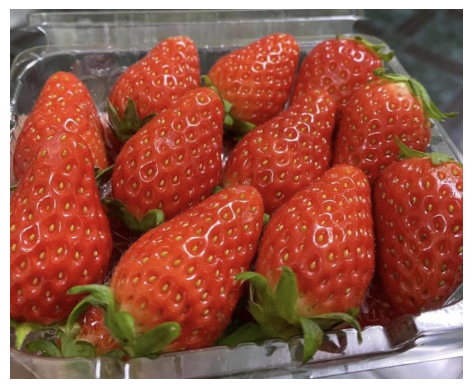

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step
------------------------------
🎯 KẾT QUẢ: Chín (Ripe)
📊 Độ tự tin: 64.95%
Chi tiết (Ripe | Rotten | Unripe): [0.6495331  0.34958667 0.00088023]
------------------------------


In [ ]:
import requests
from PIL import Image
from io import BytesIO

def test_url_image(url):
    # Tải ảnh từ URL về máy ảo Colab
    response = requests.get(url)
    img = Image.open(BytesIO(response.content))
    temp_path = "temp_test_image.jpg"
    img.save(temp_path)

    # Gọi hàm dự đoán với file đã tải
    test_my_model(temp_path)

# Thử nghiệm với link ảnh của bạn
test_url_image("https://cdnphoto.dantri.com.vn/drcUuqLkJxQzjoL8XjmI3TU89Pg=/thumb_w/1360/2023/09/16/img1895-2-1694871719687.jpg")

Đang phân tích ảnh...



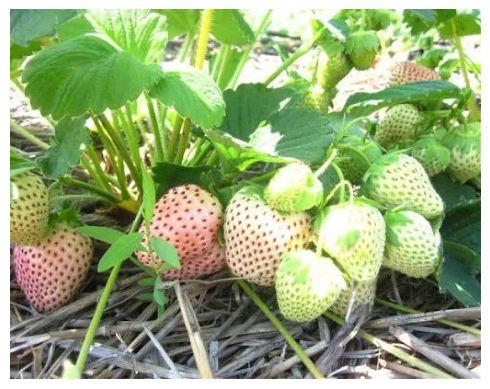

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
------------------------------
🎯 KẾT QUẢ: Hư hỏng/Thối (Rotten)
📊 Độ tự tin: 79.32%
Chi tiết (Ripe | Rotten | Unripe): [1.3379123e-12 7.9323161e-01 2.0676842e-01]
------------------------------


In [ ]:
import requests
from PIL import Image
from io import BytesIO

def test_url_image(url):
    # Tải ảnh từ URL về máy ảo Colab
    response = requests.get(url)
    img = Image.open(BytesIO(response.content))
    temp_path = "temp_test_image.jpg"
    img.save(temp_path)

    # Gọi hàm dự đoán với file đã tải
    test_my_model(temp_path)

# Thử nghiệm với link ảnh của bạn
test_url_image("https://img.lazcdn.com/g/p/11c089d356e798a7d15b1832e6d9bb11.jpg_720x720q80.jpg_.webp")

## kiểm tra local

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# 1. Tải mô hình đã lưu
model = tf.keras.models.load_model('/content/fruit_ripeness_model.h5')

# 2. Định nghĩa từ điển nhãn (Labels)
class_labels = {
    0: 'Chín (Ripe)',
    1: 'Hư hỏng/Thối (Rotten)',
    2: 'Còn xanh (Unripe)'
}

def test_my_model1(img_path):
    print("Đang phân tích ảnh...\n")

    # --- BƯỚC A: HIỂN THỊ ẢNH ---
    img_show = image.load_img(img_path)
    plt.imshow(img_show)
    plt.axis('off')
    plt.show()

    # --- BƯỚC B: TIỀN XỬ LÝ ẢNH (Phải khớp với size lúc Train: 224x224) ---
    # Cập nhật từ 128x128 lên 224x224
    img = image.load_img(img_path, target_size=(224, 224))
    # 2. Chuyển ảnh thành ma trận số
    img_array = image.img_to_array(img)
    # 3. Chuẩn hóa pixel (chia 255)
    img_array = img_array / 255.0
    # 4. Thêm chiều dữ liệu (Batch)
    img_array = np.expand_dims(img_array, axis=0)

    # --- BƯỚC C: DỰ ĐOÁN ---
    predictions = model.predict(img_array)

    # Lấy ra vị trí có xác suất cao nhất
    predicted_class_index = np.argmax(predictions[0])

    # Lấy tên nhãn và độ tự tin (phần trăm)
    predicted_label = class_labels[predicted_class_index]
    confidence = predictions[0][predicted_class_index] * 100

    print("-" * 30)
    print(f"🎯 KẾT QUẢ: {predicted_label}")
    print(f"📊 Độ tự tin: {confidence:.2f}%")
    print(f"Chi tiết (Ripe | Rotten | Unripe): {predictions[0]}")
    print("-" * 30)

print("Đã tải xong hàm dự đoán! Sẵn sàng test ảnh.")

Đã tải xong hàm dự đoán! Sẵn sàng test ảnh.


## Chuyển model


In [ ]:
# !cp /content/drive/MyDrive/machine_learning/Model/fruit_ripeness_model.h5 /content/
!pip install tensorflowjs
!tensorflowjs_converter --input_format=keras fruit_ripeness_model.h5 tfjs_model/
!zip -r tfjs_model.zip tfjs_model/

2026-04-16 01:55:09.992979: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776304510.014107   20763 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776304510.020741   20763 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776304510.036598   20763 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776304510.036651   20763 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776304510.036655   20763 computation_placer.cc:177] computation placer alr